<a href="https://colab.research.google.com/github/kamathvk1982/GAI601/blob/main/AssignmentTwo-EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading of Libraries

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


Load data and analyze the data sample and data structure

In [21]:
url = "https://raw.githubusercontent.com/kamathvk1982/GAI601/main/bank-full.csv"
df = pd.read_csv(url, sep=';')  # UCI bank marketing uses ';' as separator

print("Shape:", df.shape)
print("\nHead:")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nTarget distribution (y):")
print(df['y'].value_counts(normalize=True))


Shape: (45211, 17)

Head:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Da

We can see from above that <<>>



now lets perform Exploratory Data analysis, answer the following questions:

#### 1. Are the features correlated?


Correlation matrix (numeric + encoded categoricals):
                age       job   marital  education   default   balance  \
age        1.000000 -0.021868 -0.403240  -0.106807 -0.017879  0.097783   
job       -0.021868  1.000000  0.062045   0.166707 -0.006853  0.018232   
marital   -0.403240  0.062045  1.000000   0.108576 -0.007023  0.002122   
education -0.106807  0.166707  0.108576   1.000000 -0.010718  0.064514   
default   -0.017879 -0.006853 -0.007023  -0.010718  1.000000 -0.066745   
balance    0.097783  0.018232  0.002122   0.064514 -0.066745  1.000000   
housing   -0.185513 -0.125363 -0.016096  -0.090790 -0.006025 -0.068768   
loan      -0.015655 -0.033004 -0.046893  -0.048574  0.077234 -0.084350   
contact    0.026221 -0.082063 -0.039201  -0.110928  0.015404 -0.027273   
day       -0.009120  0.022856 -0.005261   0.022671  0.009424  0.004503   
month     -0.042357 -0.092870 -0.006991  -0.057304  0.011486  0.019777   
duration  -0.004648  0.004744  0.011852   0.001935 -0.0100

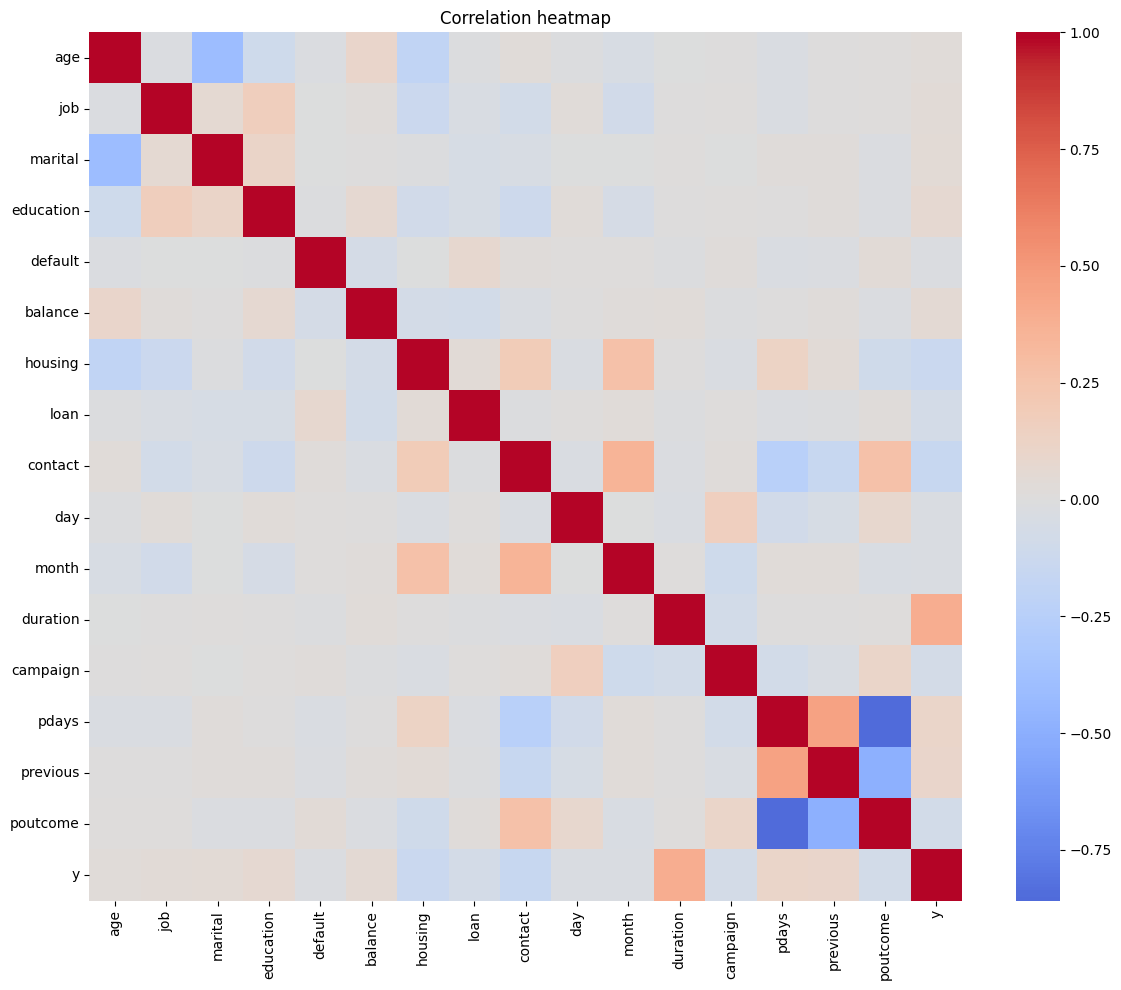

In [22]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr = df_encoded.corr(numeric_only=True)

print("\nCorrelation matrix (numeric + encoded categoricals):")
print(corr)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()


We can see from above that <<>>


#### 2. Check for potential data leakage


In [23]:
print("\nColumns:")
print(df.columns.tolist())

# Heuristic: print columns that look like post-outcome info
suspect_cols = [c for c in df.columns if 'poutcome' in c.lower() or 'previous' in c.lower()]
print("\nPotential leakage-related columns (to inspect manually):", suspect_cols)
print(df[suspect_cols].head())



Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Potential leakage-related columns (to inspect manually): ['previous', 'poutcome']
   previous poutcome
0         0  unknown
1         0  unknown
2         0  unknown
3         0  unknown
4         0  unknown


We can see from above that <<>>


#### 3. Overall distribution of each variable



Summary statistics for numeric variables:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000 

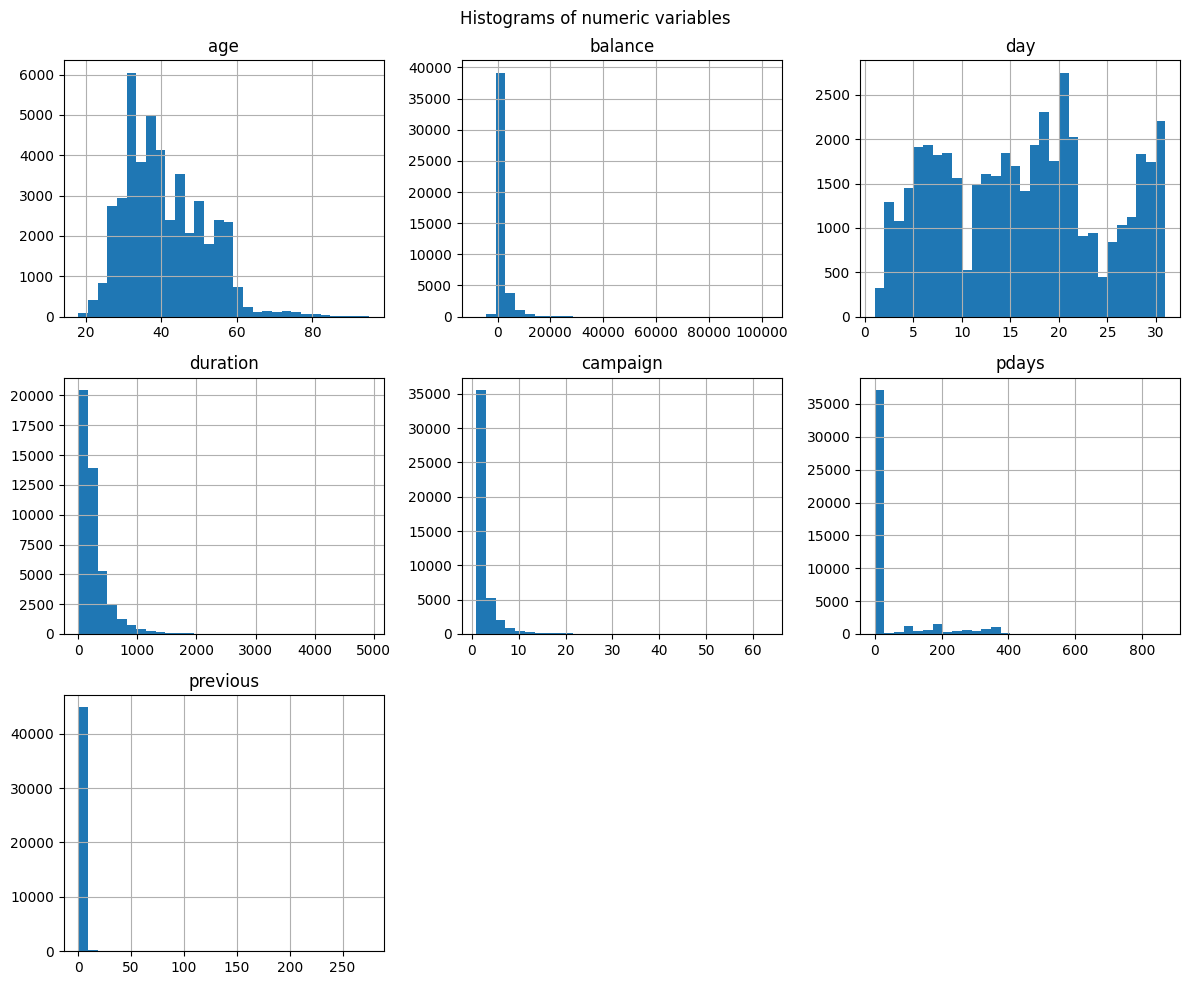

In [12]:
print("\nSummary statistics for numeric variables:")
print(df.describe())

print("\nValue counts for categorical variables:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(normalize=True).head(10))

# Optional: histograms for numeric variables
df.select_dtypes(include=[np.number]).hist(figsize=(12, 10), bins=30)
plt.suptitle("Histograms of numeric variables")
plt.tight_layout()
plt.show()


We can see from above that <<>>



#### 4. Outliers (using IQR rule for numeric columns)



Outlier report (IQR method):
age -> {'lower_bound': np.float64(10.5), 'upper_bound': np.float64(70.5), 'num_outliers': np.int64(487), 'pct_outliers': np.float64(0.010771714848156422)}
balance -> {'lower_bound': np.float64(-1962.0), 'upper_bound': np.float64(3462.0), 'num_outliers': np.int64(4729), 'pct_outliers': np.float64(0.10459843843312468)}
day -> {'lower_bound': np.float64(-11.5), 'upper_bound': np.float64(40.5), 'num_outliers': np.int64(0), 'pct_outliers': np.float64(0.0)}
duration -> {'lower_bound': np.float64(-221.0), 'upper_bound': np.float64(643.0), 'num_outliers': np.int64(3235), 'pct_outliers': np.float64(0.07155338302625468)}
campaign -> {'lower_bound': np.float64(-2.0), 'upper_bound': np.float64(6.0), 'num_outliers': np.int64(3064), 'pct_outliers': np.float64(0.06777111764835991)}
pdays -> {'lower_bound': np.float64(-1.0), 'upper_bound': np.float64(-1.0), 'num_outliers': np.int64(8257), 'pct_outliers': np.float64(0.18263254517705868)}
previous -> {'lower_bound': np.floa

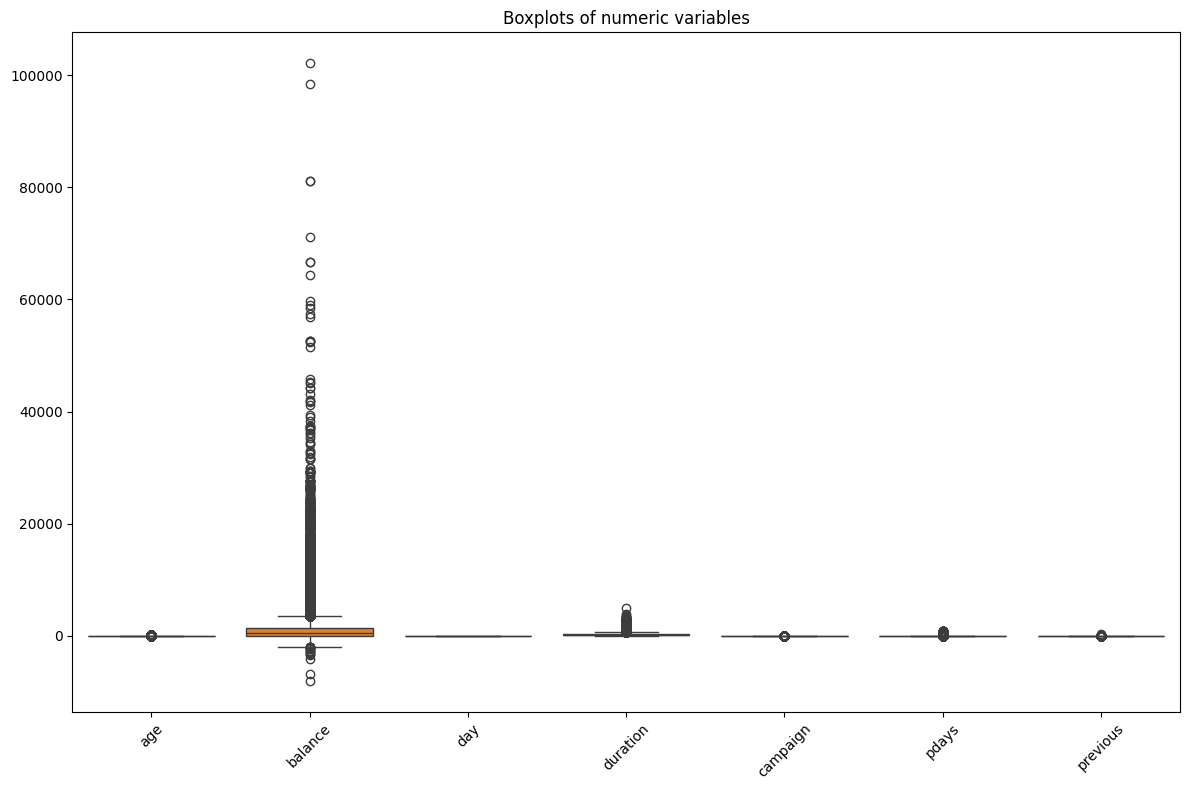

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_report = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "num_outliers": outliers,
        "pct_outliers": outliers / len(df)
    }

print("\nOutlier report (IQR method):")
for col, stats in outlier_report.items():
    print(col, "->", stats)

# Boxplots for numeric variables
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots of numeric variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


We can see from above that <<>>

#### 5. Relationships between different variables


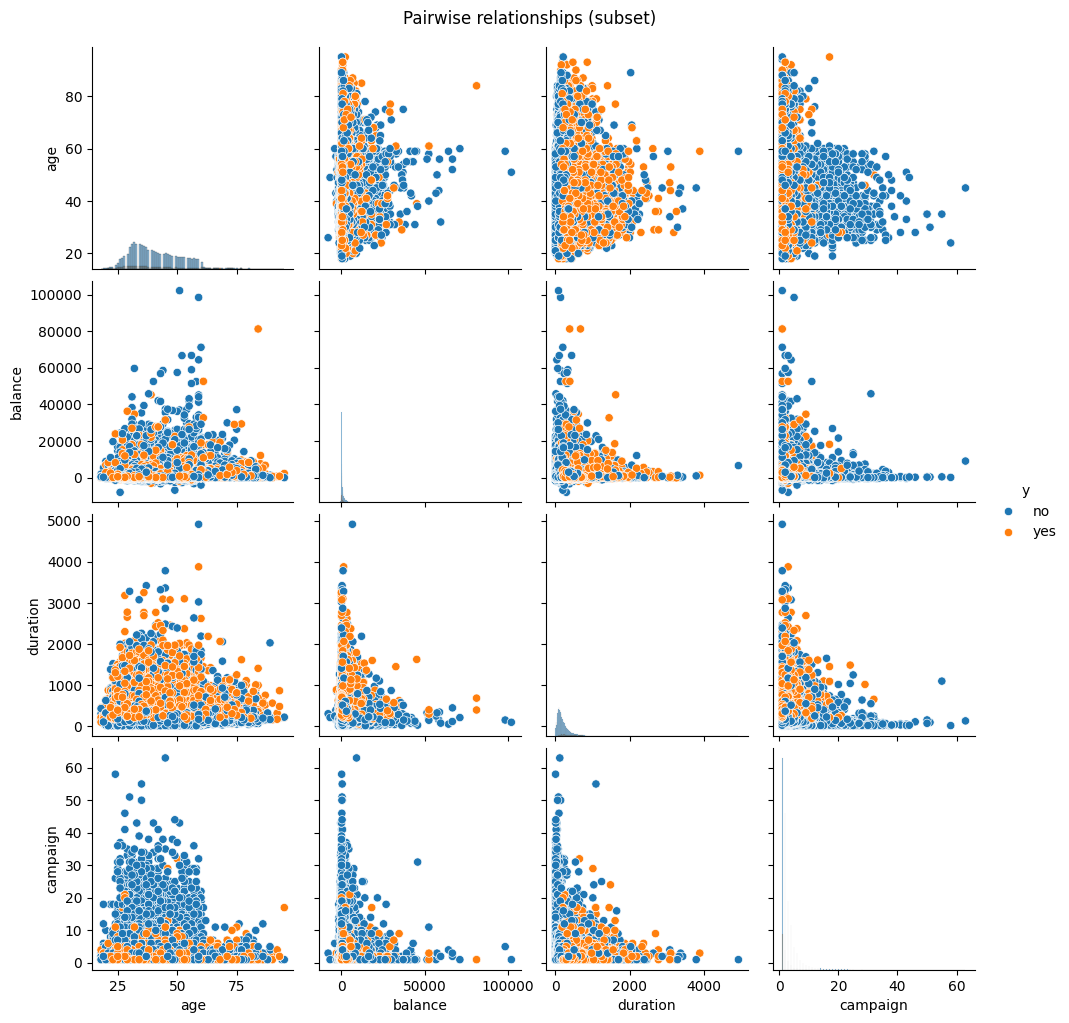

In [14]:
subset = ['age', 'balance', 'duration', 'campaign']
subset = [c for c in subset if c in df.columns]

if subset:
    sns.pairplot(df[subset + ['y']], hue='y', diag_kind='hist')
    plt.suptitle("Pairwise relationships (subset)", y=1.02)
    plt.show()


We can see from above that <<>>

#### 6. Distribution of categorical variables


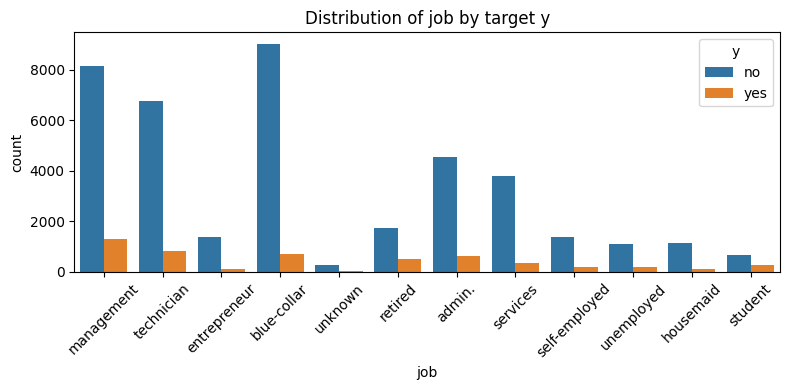

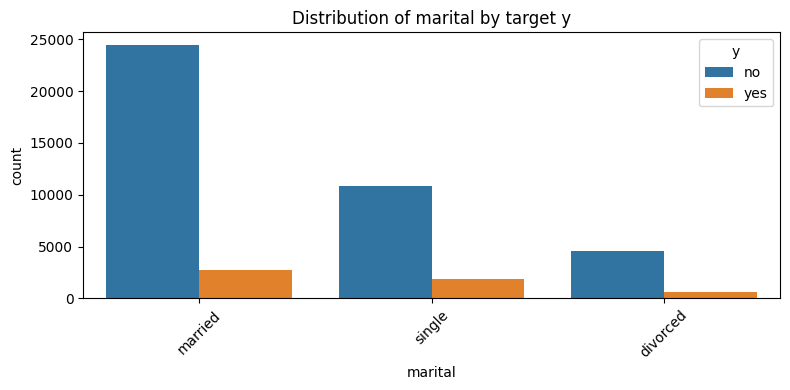

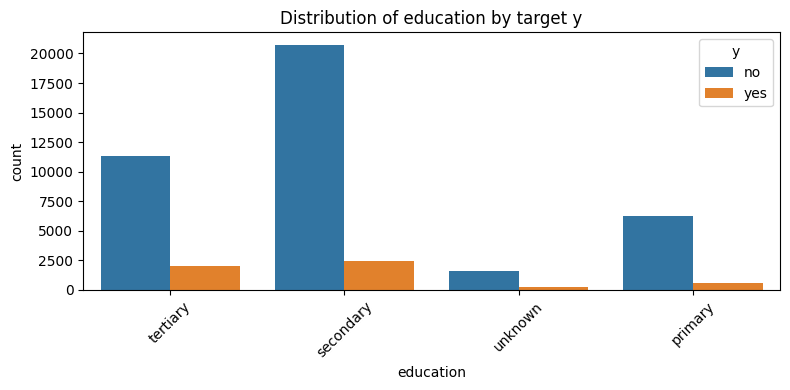

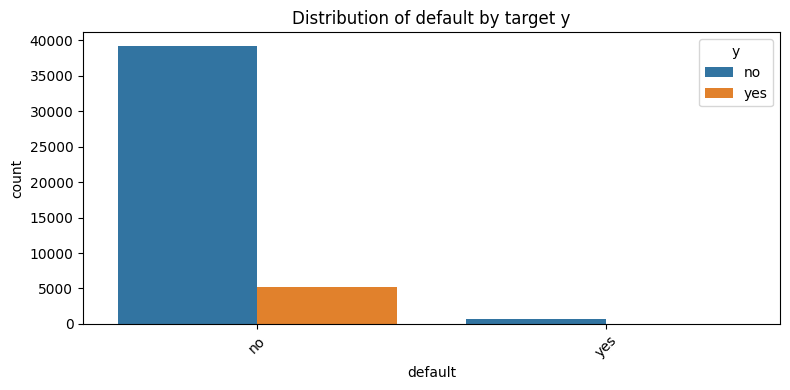

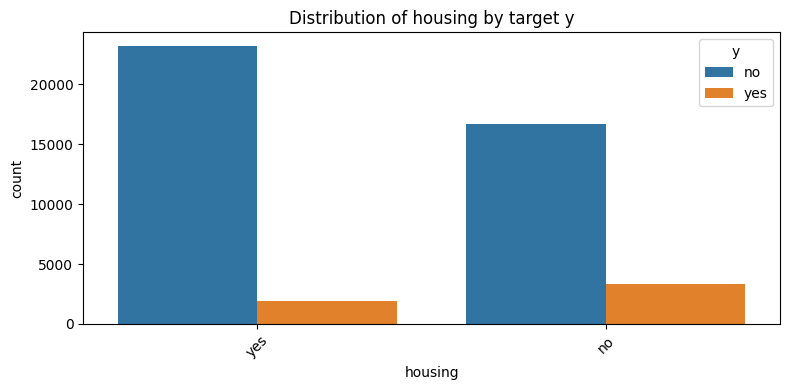

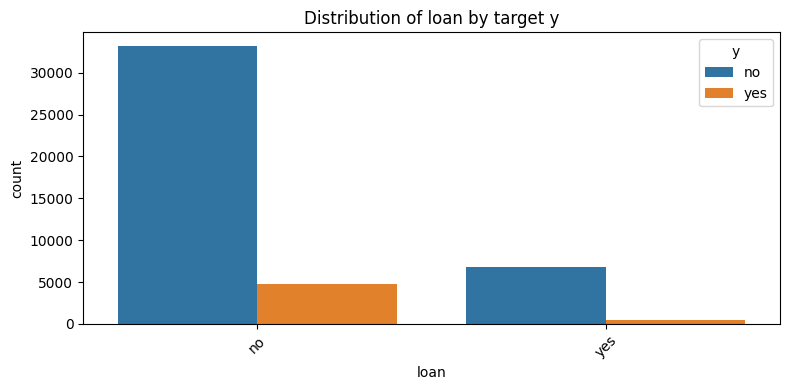

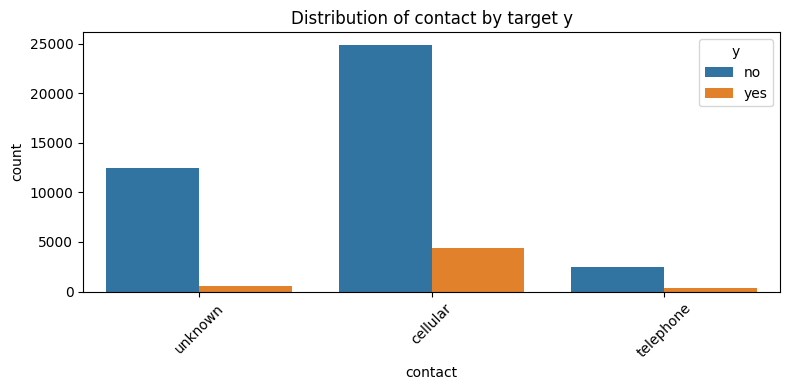

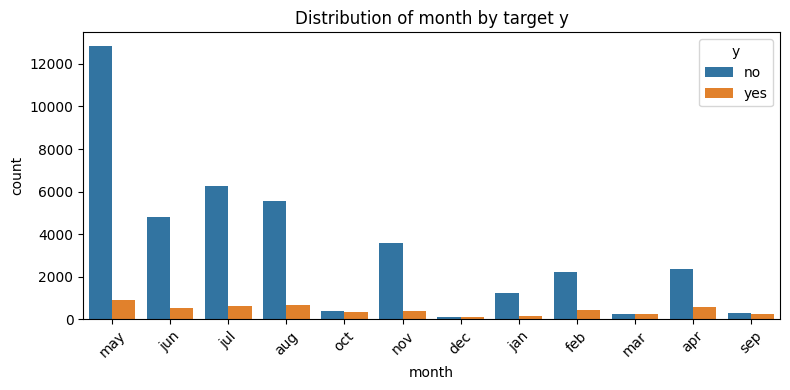

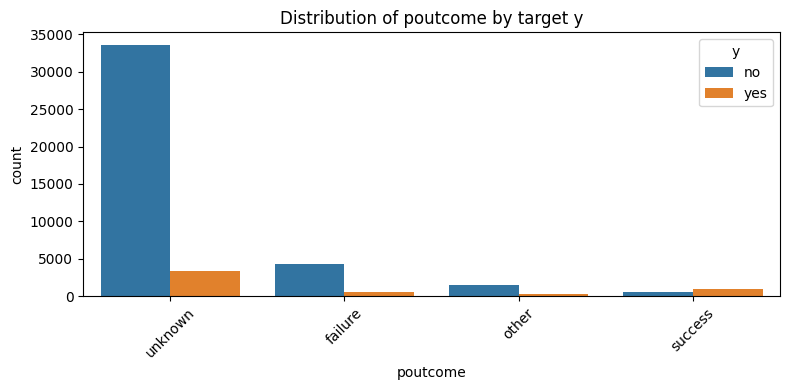

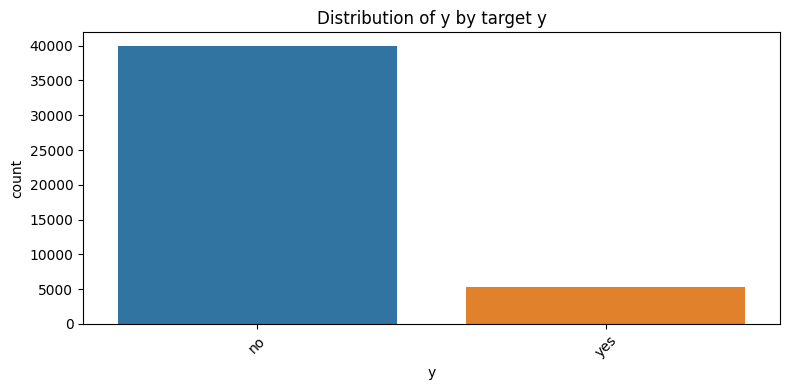

In [15]:
for col in df.select_dtypes(include=['object']).columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='y')
    plt.title(f"Distribution of {col} by target y")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


We can see from above that <<>>

#### 7. Patterns or trends (simple examples)


In [16]:
# Example: subscription rate by job and marital status
if 'job' in df.columns and 'marital' in df.columns:
    job_marital = pd.crosstab(df['job'], df['y'], normalize='index')
    print("\nSubscription rate by job:")
    print(job_marital.sort_values('yes', ascending=False).head(10))

    marital_rate = pd.crosstab(df['marital'], df['y'], normalize='index')
    print("\nSubscription rate by marital status:")
    print(marital_rate)



Subscription rate by job:
y                    no       yes
job                              
student        0.713220  0.286780
retired        0.772085  0.227915
unemployed     0.844973  0.155027
management     0.862444  0.137556
admin.         0.877973  0.122027
self-employed  0.881571  0.118429
unknown        0.881944  0.118056
technician     0.889430  0.110570
services       0.911170  0.088830
housemaid      0.912097  0.087903

Subscription rate by marital status:
y               no       yes
marital                     
divorced  0.880545  0.119455
married   0.898765  0.101235
single    0.850508  0.149492


We can see from above that <<>>

#### 8. Central tendency and spread (already partly in describe())


In [17]:
print("\nCentral tendency and spread (numeric):")
desc = df.describe().T
desc['median'] = df[numeric_cols].median()
print(desc[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']])



Central tendency and spread (numeric):
                 mean  median          std     min    25%    50%     75%  \
age         40.936210    39.0    10.618762    18.0   33.0   39.0    48.0   
balance   1362.272058   448.0  3044.765829 -8019.0   72.0  448.0  1428.0   
day         15.806419    16.0     8.322476     1.0    8.0   16.0    21.0   
duration   258.163080   180.0   257.527812     0.0  103.0  180.0   319.0   
campaign     2.763841     2.0     3.098021     1.0    1.0    2.0     3.0   
pdays       40.197828    -1.0   100.128746    -1.0   -1.0   -1.0    -1.0   
previous     0.580323     0.0     2.303441     0.0    0.0    0.0     0.0   

               max  
age           95.0  
balance   102127.0  
day           31.0  
duration    4918.0  
campaign      63.0  
pdays        871.0  
previous     275.0  


We can see from above that <<>>

#### 9. Missing values and duplicates


In [18]:
print("\nMissing values per column:")
print(df.isna().sum())

num_duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", num_duplicates)



Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Number of duplicate rows: 0


We can see from above that <<>>

#### 10. Recommendations (printed as text)


In [19]:
print("\n--- Recommendations ---")

# Data cleaning
print("- Data cleaning: handle outliers in numeric columns (e.g., 'balance', 'duration') via capping or transformation.")
print("- Consider dropping or carefully encoding high-cardinality categoricals if any (e.g., 'job', 'contact').")

# Data leakage
print("- Potential leakage: columns like 'poutcome' and 'previous' may encode information from past campaigns;")
print("  decide whether they are known at prediction time. If not, drop or treat carefully.")

# Imbalance
print("- Class imbalance: inspect y distribution above; if heavily skewed, consider class weights,")
print("  resampling (SMOTE/undersampling), or appropriate metrics (AUC, F1).")

# Dimensionality reduction / sampling
print("- Dimensionality reduction: one-hot encoding may create many features; consider target encoding or")
print("  tree-based models that handle categoricals well, or use PCA on numeric subset if needed.")
print("- Data sampling: if dataset is very large, you can downsample for quick experimentation,")
print("  then train final models on full data.")



--- Recommendations ---
- Data cleaning: handle outliers in numeric columns (e.g., 'balance', 'duration') via capping or transformation.
- Consider dropping or carefully encoding high-cardinality categoricals if any (e.g., 'job', 'contact').
- Potential leakage: columns like 'poutcome' and 'previous' may encode information from past campaigns;
  decide whether they are known at prediction time. If not, drop or treat carefully.
- Class imbalance: inspect y distribution above; if heavily skewed, consider class weights,
  resampling (SMOTE/undersampling), or appropriate metrics (AUC, F1).
- Dimensionality reduction: one-hot encoding may create many features; consider target encoding or
  tree-based models that handle categoricals well, or use PCA on numeric subset if needed.
- Data sampling: if dataset is very large, you can downsample for quick experimentation,
  then train final models on full data.


We can see from above that <<>>